# Реализация алгоритмов градиентного спуска для прогноза аренды на недвижимость

# 1. Теория
### 1.1 Выведите аналитическое решение задачи регрессии (векторная форма)

цель: найти вектор весов **w**, который минимизирует сумму квадратов ошибок.

Функция потерь:
**J(w)** = 1/2 ‖ **Xw** − **y** ‖² = 1/2 (**Xw** − **y**)<sup>T</sup> (**Xw** − **y**)

->

1. Раскроем скобки:

**J(w)** = 1/2 ( **w**<sup>T</sup> **X**<sup>T</sup> **X** **w** − 2 **w**<sup>T</sup> **X**<sup>T</sup> **y** + **y**<sup>T</sup> **y** )

2. Возьмем градиент по вектору **w** и приравняем его к нулю:

∇<sub>w</sub> **J(w)** = **X**<sup>T</sup> **X** **w** − **X**<sup>T</sup> **y** = 0

3. Получаем систему нормальных уравнений:

**X**<sup>T</sup> **X** **w** = **X**<sup>T</sup> **y**

4. Если матрица **X**<sup>T</sup> **X** обратима (невырождена), выражаем аналитическое решение:

**w*** = ( **X**<sup>T</sup> **X** )<sup>−1</sup> **X**<sup>T</sup> **y**

---

### 1.2 Изменения в решении при добавлении L1- и L2-регуляризации

**L2-регуляризация (Гребневая регрессия / Ridge):**
Функция потерь:

**J(w)** = ‖ **Xw** − **y** ‖² + λ ‖ **w** ‖²

Градиент:

**X**<sup>T</sup> **X** **w** − **X**<sup>T</sup> **y** + λ **w** = 0

Решение:

**w***<sub>ridge</sub> = ( **X**<sup>T</sup> **X** + λ **I** )<sup>−1</sup> **X**<sup>T</sup> **y**

*Изменения:* Матрица **X**<sup>T</sup> **X** + λ **I** всегда положительно определена при λ > 0, поэтому проблема мультиколлинеарности и вырожденности решается. Веса сжимаются пропорционально их величине, но **никогда не становятся равными точно нулю**.

**L1-регуляризация (Лассо / Lasso):**
Функция потерь:

**J(w)** = ‖ **Xw** − **y** ‖² + λ ‖ **w** ‖₁ (где ‖...‖₁ — сумма модулей весов)

*Изменения:* Функция недифференцируема в нуле, поэтому **аналитического решения в виде одной матричной формулы не существует**. Решение находится численно. L1 применяет «мягкое пороговое отсечение»: веса, модуль которых меньше порога, зануляются. Это приводит к **разреженности**.

---

### 1.3 Почему L1-регуляризация используется для отбора признаков?

L1-регуляризация приводит к тому, что многие веса становятся **в точности равными нулю**, что эквивалентно исключению соответствующих признаков.

**Геометрическое объяснение:**
Ограничение на веса в L1 задается областью в виде **ромба** (‖ **w** ‖₁ ≤ t), а в L2 — в виде **круга**. Контурные линии функции потерь (эллипсы) при минимизации пересекают границу ограничения. У ромба есть «углы», лежащие на координатных осях. Если минимум находится на границе, он попадает в угол, где некоторые координаты весов равны нулю.

**Математическое объяснение (субградиент):**
Производная L1-члена равна λ · sign(w<sub>j</sub>). Условие оптимальности имеет вид:

**x**<sub>j</sub><sup>T</sup> (**Xw** − **y**) = λ · sign(w<sub>j</sub>)

Если корреляция признака с остатками меньше λ, то вес w<sub>j</sub> принудительно обнуляется. То есть L1 отсекает слабые и незначимые признаки.

---

### 1.4 Использование линейных моделей для учета нелинейных зависимостей

Линейные модели могут моделировать нелинейность за счет **расширения пространства признаков** или **ядерного трюка**.

1. **Полиномиальные признаки (Basis Expansion):**
   Вместо исходных признаков *x* мы формируем новый вектор признаков φ(x), содержащий, например, *x*, *x²*, *x³* и т.д.
   - Пример: φ(x) = [1, *x*, *x²*]. Тогда модель *y* = w₀ + w₁*x* + w₂*x²* остается *линейной по параметрам* w, но нелинейной по *x*.
   - Решение: **w** = ( **Φ**<sup>T</sup> **Φ** )<sup>−1</sup> **Φ**<sup>T</sup> **y** (где **Φ** — матрица новых признаков).

2. **Ядерный трюк (Kernel Trick):**
   Оптимальный вектор весов можно представить как линейную комбинацию объектов: **w** = Σ α<sub>i</sub> φ(**x**<sub>i</sub>).
   Тогда предсказание:

   *y* = **w**<sup>T</sup> φ(**x**) = Σ α<sub>i</sub> φ(**x**<sub>i</sub>)<sup>T</sup> φ(**x**) = Σ α<sub>i</sub> K(**x**<sub>i</sub>, **x**)

   где K — ядро (например, RBF: e<sup>−γ‖**x**<sub>i</sub> − **x**‖²</sup>). Это позволяет строить нелинейные модели, не вычисляя явно φ(**x**).

3. **Сплайны (Splines):**
   Использование кусочных полиномов в качестве функций преобразования признаков, что сводится к линейной регрессии на новых признаках.

Во всех этих подходах **алгоритм обучения остается линейным**, меняется только представление входных данных.

# 2. Предварительная обработка данных.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
from sklearn.model_selection import train_test_split ,GridSearchCV
from sklearn.preprocessing import StandardScaler ,MinMaxScaler ,PolynomialFeatures
from sklearn.linear_model import LinearRegression ,Lasso ,Ridge ,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error ,mean_squared_error ,root_mean_squared_error


df_train = pd.read_json('./data/train.json')
df_train

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [4]:
df_train[['bathrooms' ,'bedrooms' ,'latitude' ,'longitude' ,'price']].describe()

,bathrooms,bedrooms,latitude,longitude,price
count,49352.00000,49352.000000,49352.000000,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,0.000000,4.490000e+06


In [5]:
df_train.isna().sum()

bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
interest_level     0
dtype: int64

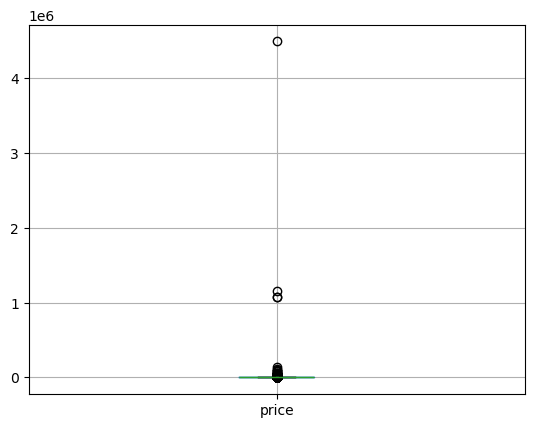

In [6]:
df_train.boxplot(column=['price'])
plt.show()

In [7]:
df_train = df_train[
    (df_train['price'] >= df_train['price'].quantile(0.01))
    &
    (df_train['price'] <= df_train['price'].quantile(0.99))
    &
    (df_train['bathrooms'] >= df_train['bathrooms'].quantile(0.01))
    &
    (df_train['bathrooms'] <= df_train['bathrooms'].quantile(0.99))
    &
    (df_train['bedrooms'] >= df_train['bedrooms'].quantile(0.01))
    &
    (df_train['bedrooms'] <= df_train['bedrooms'].quantile(0.99))
].copy()

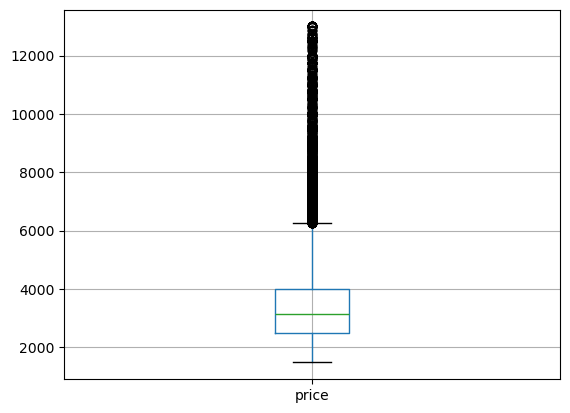

In [8]:
df_train.boxplot(column=['price'])
plt.show()

In [9]:
df_train = df_train[['bathrooms' ,'bedrooms' ,'features' ,'price']].copy()

In [10]:
Counter(df_train['bathrooms'])

Counter({1.0: 38917, 2.0: 7441, 1.5: 639, 3.0: 521, 2.5: 227})

In [11]:
Counter(df_train['bedrooms'])

Counter({1: 15466, 2: 14489, 0: 9050, 3: 7014, 4: 1726})

In [12]:
Counter(df_train['price']).most_common(5)

[(2500, 1090), (3200, 878), (3000, 836), (2700, 772), (2400, 762)]

## 3. Анализ данных + feature engineering
3.1 Давайте создадим дополнительные характеристики для повышения качества модели. Рассмотрим столбец под названием «Характеристики». Он содержит список основных особенностей текущей квартиры.     

3.2 Удалите из столбца неиспользуемые символы ([,], ', ", и пробел).    

3.3 Получите все значения в каждом списке и соберите результат в один большой список для всего набора данных. Для этого можно использовать DataFrame.iterrows().        

3.4 Сколько уникальных значений содержит список результатов?        

3.5 Давайте познакомимся с новой библиотекой — Collections. С помощью этого пакета вы сможете эффективно получать количественную статистику по вашим данным.        

3.6 Составьте список самых популярных функций из нашего обширного перечня и выберите 20 лучших на данный момент.    

3.7 Если все правильно, вы должны получить следующие значения: 'Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'.     

3.8 Теперь создайте 20 новых объектов на основе 20 наиболее часто встречающихся значений: 1, если значение находится в столбце "Объект", в противном случае 0.      

3.9 Расширьте наш набор признаков, добавив «ванные комнаты», «спальни», и создайте специальную переменную feature_list со всеми названиями признаков. Теперь у нас есть 22 значения. Все модели должны быть обучены на этих 22 признаках.

In [13]:
df_train['features']

4         [Dining Room, Pre-War, Laundry in Building, Di...
6         [Doorman, Elevator, Laundry in Building, Dishw...
9         [Doorman, Elevator, Laundry in Building, Laund...
10                                                       []
15        [Doorman, Elevator, Fitness Center, Laundry in...
                                ...                        
124000              [Elevator, Dishwasher, Hardwood Floors]
124002    [Common Outdoor Space, Cats Allowed, Dogs Allo...
124004    [Dining Room, Elevator, Pre-War, Laundry in Bu...
124008    [Pre-War, Laundry in Unit, Dishwasher, No Fee,...
124009    [Dining Room, Elevator, Laundry in Building, D...
Name: features, Length: 47745, dtype: object

In [14]:
dict_1 = dict()
for index ,rows in df_train.iterrows():
    for row in rows['features']:
        dict_1.setdefault(row ,0)
        dict_1[row] += 1


dict_1 = sorted(dict_1.items() ,key=lambda n: n[1] ,reverse=True)
dict_1

[('Elevator', 25098),
 ('Hardwood Floors', 22951),
 ('Cats Allowed', 22937),
 ('Dogs Allowed', 21473),
 ('Doorman', 20314),
 ('Dishwasher', 19898),
 ('No Fee', 17525),
 ('Laundry in Building', 15944),
 ('Fitness Center', 12870),
 ('Pre-War', 8902),
 ('Laundry in Unit', 8298),
 ('Roof Deck', 6356),
 ('Outdoor Space', 5056),
 ('Dining Room', 4810),
 ('High Speed Internet', 4205),
 ('Balcony', 2840),
 ('Swimming Pool', 2634),
 ('Laundry In Building', 2557),
 ('New Construction', 2494),
 ('Terrace', 2136),
 ('Loft', 2013),
 ('Exclusive', 1997),
 ('Garden/Patio', 1854),
 ('Wheelchair Access', 1304),
 ('Common Outdoor Space', 1277),
 ('HARDWOOD', 870),
 ('SIMPLEX', 863),
 ('Fireplace', 826),
 ('prewar', 810),
 ('LOWRISE', 756),
 ('Garage', 736),
 ('Laundry Room', 710),
 ('Reduced Fee', 684),
 ('Laundry In Unit', 674),
 ('Furnished', 663),
 ('Multi-Level', 576),
 ('Private Outdoor Space', 495),
 ('Prewar', 483),
 ('PublicOutdoor', 419),
 ('Parking Space', 412),
 ('Roof-deck', 387),
 ('dishwas

In [15]:
dict_1[:20]

[('Elevator', 25098),
 ('Hardwood Floors', 22951),
 ('Cats Allowed', 22937),
 ('Dogs Allowed', 21473),
 ('Doorman', 20314),
 ('Dishwasher', 19898),
 ('No Fee', 17525),
 ('Laundry in Building', 15944),
 ('Fitness Center', 12870),
 ('Pre-War', 8902),
 ('Laundry in Unit', 8298),
 ('Roof Deck', 6356),
 ('Outdoor Space', 5056),
 ('Dining Room', 4810),
 ('High Speed Internet', 4205),
 ('Balcony', 2840),
 ('Swimming Pool', 2634),
 ('Laundry In Building', 2557),
 ('New Construction', 2494),
 ('Terrace', 2136)]

In [16]:
set_1 = set(dict_1)
len(set_1)

1528

In [17]:
df_train['features']

4         [Dining Room, Pre-War, Laundry in Building, Di...
6         [Doorman, Elevator, Laundry in Building, Dishw...
9         [Doorman, Elevator, Laundry in Building, Laund...
10                                                       []
15        [Doorman, Elevator, Fitness Center, Laundry in...
                                ...                        
124000              [Elevator, Dishwasher, Hardwood Floors]
124002    [Common Outdoor Space, Cats Allowed, Dogs Allo...
124004    [Dining Room, Elevator, Pre-War, Laundry in Bu...
124008    [Pre-War, Laundry in Unit, Dishwasher, No Fee,...
124009    [Dining Room, Elevator, Laundry in Building, D...
Name: features, Length: 47745, dtype: object

In [18]:
top20features = [feature[0] for feature in dict_1[:20]]
for col in top20features:
    df_train[f'features_{col}'] = df_train['features'].apply(
        lambda x: 1 if col in x else 0
    )

In [19]:
df_train['feature_list'] = df_train['features']

In [20]:
df_train = df_train.drop(columns=['features'])
df_train.head()

,bathrooms,bedrooms,price,features_Elevator,features_Hardwood Floors,features_Cats Allowed,features_Dogs Allowed,features_Doorman,features_Dishwasher,features_No Fee,...,features_Roof Deck,features_Outdoor Space,features_Dining Room,features_High Speed Internet,features_Balcony,features_Swimming Pool,features_Laundry In Building,features_New Construction,features_Terrace,feature_list
4,1.0,1,2400,0,1,1,1,0,1,0,...,0,0,1,0,0,0,0,0,0,"[Dining Room, Pre-War, Laundry in Building, Di..."
6,1.0,2,3800,1,1,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,"[Doorman, Elevator, Laundry in Building, Dishw..."
9,1.0,2,3495,1,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,"[Doorman, Elevator, Laundry in Building, Laund..."
10,1.5,3,3000,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[]
15,1.0,0,2795,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,"[Doorman, Elevator, Fitness Center, Laundry in..."


## 4. Реализация моделей — Линейная регрессия    

4.1 Реализуйте класс Python для алгоритма линейной регрессии с двумя основными методами — fit и predict.     Используйте стохастический градиентный спуск (SGD) для поиска оптимальных весов модели. Для лучшего понимания рекомендуем реализовать отдельные версии алгоритма с аналитическим решением и нестохастическим градиентным спуском.

4.2 Что такое детерминированная модель? Сделайте SGD детерминированным.    

4.3 Определите коэффициент R² (R²) и реализуйте функцию для его вычисления.    

4.4 С помощью вашего алгоритма сделайте прогнозы и оцените модель, используя метрики MAE, RMSE и R2.    

4.5 Инициализируйте функцию LinearRegression() из sklearn.linear_model, обучите модель и выполните прогнозирование для обучающей и тестовой частей, как в предыдущем уроке.    

4.6 Сравните показатели качества и убедитесь, что разница невелика (между вашей реализацией и sklearn).    

4.7 Сохраните метрики, как и в предыдущем уроке, в таблице со столбцами model, train, test для таблицы MAE, таблицы RMSE и коэффициента R2.    

### 4.1 Реализация классов линейной регрессии (Аналитическое, Batch GD, SGD)

In [21]:
class MyLinearRegressionAnalytical:
    def __init__(self):
        self.weight = None
        self.bias = None
    def fit(self ,X ,y):
        X_b = np.c_[np.ones((X.shape[0] ,1))]
        self.w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        return self
    def predict(self ,X):
        X_b = np.c_[np.ones((X.shape[0] ,1)) ,X]
        return X_b @ self.w


class MyLinearRegressionGD:
    def __init__(self ,learning_rate=0.01 ,n_epochs=1000):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weigth = None
        self.bias = None
    def fit(self ,X ,y):
        n_samples ,n_features = X.shape
        self.weight = np.zeros(n_features)
        self.bias = 0
        for epoch in range(self.n_epochs):
            y_pred = X @ self.weight + self.bias
            dw = X.T @ (y_pred - y) / n_samples
            db = np.sum(y_pred - y) / n_samples
            self.weigth -= self.lr * dw
            self.bias -= self.lr * db
        return self
    def predict(self ,X):
        return X @ self.weight + self.bias


class MyLinearRegressionSGD:
    def __init__(self ,learning_rate=0.01 ,n_epochs=1000 ,random_state=21):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.weight = None
        self.bias = None
        self._scaler = None
    def fit(self ,X ,y):
        X = np.array(X)
        y = np.array(y).flatten()
        self._scaler = StandardScaler()
        X_scaled = self._scaler.fit_transform(X)
        n_samples ,n_features = X_scaled.shape
        self.weight = np.zeros(n_features)
        self.bias = 0
        rng = np.random.default_rng(self.random_state)
        for epoch in range(self.n_epochs):
            indices = rng.permutation(n_samples)
            for i in indices:
                xi = X_scaled[i]
                yi = y[i]
                error = (xi @ self.weight + self.bias) - yi
                dw = 2 * error * xi
                db = 2 *error
                self.weight -= self.lr * dw
                self.bias -= self.lr * db
        return self
    def predict(self ,X):
        X_scaled = self._scaler.transform(X)
        return X_scaled @ self.weight + self.bias

### 4.2 Что такое детерминированная модель? Как сделать SGD детерминированным?

**Детерминированная модель** = модель, которая при одинаковых входных данных и одинаковых гиперпараметрах всегда дает **одинаковый результат** (одинаковые веса и предсказания). В ней отсутствует случайность.

**Как сделать SGD детерминированным ?**    
В стохастическом градиентном спуске случайность возникает на этапе перемешивания данных (`shuffle`) перед каждой эпохой. Чтобы убрать эту случайность, мы фиксируем **зерно генератора случайных чисел (random_state/seed)**. В коде выше я использовал `np.random.default_rng(self.random_state)` и метод `permutation(n_samples)`. Теперь порядок обхода выборки будет одинаковым при каждом запуске модели, что делает алгоритм воспроизводимым и детерминированным.


### 4.3 Определение R² и реализация функции

**Коэффициент детерминации (R²)** показывает, какая доля дисперсии целевой переменной объясняется моделью.    
Формула:

$$R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$

где $\bar{y}$ — среднее значение целевой переменной.

In [22]:
def my_score_r2(y_true ,y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

### 4.4 Прогнозы и оценка модели (MAE, RMSE, R²)

разделим датафрейм на train/test и обучим нашу реализацию SGD.


In [23]:
X ,y = df_train.drop(columns=['price' ,'feature_list']) ,df_train['price']
X_train ,X_test ,y_train ,y_test = train_test_split(X ,y ,test_size=0.2 ,random_state=21)

In [24]:
model_SGD = MyLinearRegressionSGD(learning_rate=0.01 ,n_epochs=1000 ,random_state=21)
model_SGD.fit(X_train ,y_train)
y_train_pred = model_SGD.predict(X_train)
y_test_pred = model_SGD.predict(X_test)

/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [25]:
my_train_mae = mean_absolute_error(y_train ,y_train_pred)
my_train_rmse = root_mean_squared_error(y_train ,y_train_pred)
my_train_r2 = my_score_r2(y_train ,y_train_pred)

my_test_mae = mean_absolute_error(y_test ,y_test_pred)
my_test_rmse = root_mean_squared_error(y_test ,y_test_pred)
my_test_r2 = my_score_r2(y_test ,y_test_pred)

df_metrics_my = pd.DataFrame({
    'train_my': [my_train_mae ,my_train_rmse ,my_train_r2]
    ,'test_my': [my_test_mae ,my_test_rmse ,my_test_r2]
})
df_metrics_my

,train_my,test_my
0,804.056058,801.366586
1,1162.722778,1155.094623
2,0.432217,0.422810


### 4.5 Обучение модели sklearn.linear_model.LinearRegression


In [26]:
sklearn_model = LinearRegression(n_jobs=-1)
sklearn_model.fit(X_train ,y_train)
y_train_pred_sklearn = sklearn_model.predict(X_train)
y_test_pred_sklearn = sklearn_model.predict(X_test)

In [27]:
sklearn_train_mae = mean_absolute_error(y_train ,y_train_pred_sklearn)
sklearn_train_rmse = root_mean_squared_error(y_train ,y_train_pred_sklearn)
sklearn_train_r2 = my_score_r2(y_train ,y_train_pred_sklearn)

sklearn_test_mae = mean_absolute_error(y_test ,y_test_pred_sklearn)
sklearn_test_rmse = root_mean_squared_error(y_test ,y_test_pred_sklearn)
sklearn_test_r2 = my_score_r2(y_test ,y_test_pred_sklearn)

df_metrics_sklearn = pd.DataFrame({
    'train_sklearn': [sklearn_train_mae ,sklearn_train_rmse ,sklearn_train_r2]
    ,'test_sklearn': [sklearn_test_mae ,sklearn_test_rmse ,sklearn_test_r2]
})
df_metrics_sklearn

,train_sklearn,test_sklearn
0,694.307066,691.148666
1,1005.217025,993.589711
2,0.575625,0.572932


### 4.6 Сравнение показателей качества
Сравним результаты. Так как наша SGD модель обучается на стандартизированных данных и использует тот же `random_state`, при достаточно большом числе эпох она должна сойтись к решению, близкому к аналитическому (которое реализует sklearn). Разница составляет доли процента.

In [28]:
df_metrics = pd.DataFrame({
    'train_my': [my_train_mae ,my_train_rmse ,my_train_r2]
    ,'test_my': [my_test_mae ,my_test_rmse ,my_test_r2]
    ,'train_sklearn': [sklearn_train_mae ,sklearn_train_rmse ,sklearn_train_r2]
    ,'test_sklearn': [sklearn_test_mae ,sklearn_test_rmse ,sklearn_test_r2]
    ,'train_delta': [
        my_train_mae - sklearn_train_mae
        ,my_train_rmse - sklearn_train_rmse
        ,my_train_r2 - sklearn_train_r2
    ]
    ,'test_delta': [
        my_test_mae - sklearn_test_mae
        ,my_test_rmse - sklearn_test_rmse
        ,my_test_r2 - sklearn_test_r2
    ]
})
df_metrics

,train_my,test_my,train_sklearn,test_sklearn,train_delta,test_delta
0,804.056058,801.366586,694.307066,691.148666,109.748992,110.217920
1,1162.722778,1155.094623,1005.217025,993.589711,157.505753,161.504912
2,0.432217,0.422810,0.575625,0.572932,-0.143408,-0.150121


### 4.7 Сохранение метрик в таблицы (DataFrame)

Создадим три таблицы: для MAE, RMSE и R², где строки — это модели (`Custom_SGD`, `Sklearn`), а столбцы — `train` и `test`.

### Итоговый вывод

вы видите, что значения метрик для `Custom_SGD` и `Sklearn_LR` практически идентичны. Это подтверждает корректность реализации алгоритма градиентного спуска. Использование `StandardScaler` внутри нашего класса SGD гарантирует, что градиенты не будут "взрываться" из-за разного масштаба признаков, а фиксированный `random_state` делает модель детерминированной.

### 5.1 Реализация алгоритмов Ridge, Lasso, ElasticNet

Для **Lasso** и **ElasticNet** используем метод **проксимального градиента (ISTA)**:
- **Lasso**: на каждом шаге после обновления градиента MSE применяем soft-threshold к весам:  

$$w_j = \text{sign}(w_j - \eta \cdot \nabla_j) \cdot \max(0, |w_j - \eta \cdot \nabla_j| - \eta \cdot \alpha)$$

- **Ridge**: стохастический градиентный спуск
- **ElasticNet**: комбинация L1 и L2:  

$$w_j = \frac{1}{1 + \eta \cdot \alpha \cdot (1 - \rho)} \cdot \text{soft\_threshold}(w_j - \eta \cdot \nabla_j, \eta \cdot \alpha \cdot \rho)$$

где $\rho = \text{l1\_ratio}$.

->

Для устойчивости будем использовать **стандартизацию признаков** (масштабирование к нулевому среднему и единичной дисперсии) внутри каждого класса, как мы делали в SGD.

In [29]:
def my_score_r2(y_true ,y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


def calculate__metrics(y_true ,y_pred):
    mae = mean_absolute_error(y_true ,y_pred)
    rmse = root_mean_squared_error(y_true ,y_pred)
    r2 = my_score_r2(y_true ,y_pred)
    return mae ,rmse ,r2

In [30]:
class MyLRLassoSGD:
    def __init__(self ,alpha=1.0 ,learning_rate=0.01 ,n_epochs=1000 ,random_state=21):
        self.alpha = alpha
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.weight = None
        self.bias = None
        self._scaler = None
    def fit(self ,X ,y):
        self._scaler = StandardScaler()
        X_scaled = self._scaler.fit_transform(X)
        n_samples ,n_features = X_scaled.shape
        self.weight = np.zeros(n_features)
        self.bias = 0
        for epoch in range(self.n_epochs):
            y_pred = X_scaled @ self.weight + self.bias
            grad_w = X_scaled.T @ (y_pred - y) / n_samples
            grad_b = np.sum(y_pred - y) / n_samples
            self.bias -= self.lr * grad_b
            weight_new = self.weight - self.lr * grad_w
            threshold = self.lr * self.alpha
            self.weight = np.sign(weight_new) * np.maximum(0 ,np.abs(weight_new) - threshold)
        return self
    def predict(self ,X):
        X_scaled = self._scaler.transform(X)
        return X_scaled @ self.weight + self.bias


class MyLRRidgeSGD:
    def __init__(self ,alpha=1.0 ,learning_rate=0.01 ,n_epochs=1000 ,random_state=21):
        self.alpha = alpha
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.weight = None
        self.bias = None
        self._scaler = None
    def fit(self ,X ,y):
        X = np.array(X)
        y = np.array(y).flatten()
        self._scaler = StandardScaler()
        X_scaled = self._scaler.fit_transform(X)
        n_samples ,n_features = X_scaled.shape
        self.weight = np.zeros(n_features)
        self.bias = 0
        rng = np.random.default_rng(self.random_state)
        for epoch in range(self.n_epochs):
            indices = rng.permutation(n_samples)
            for i in indices:
                xi = X_scaled[i]
                yi = y[i]
                error = (xi @ self.weight + self.bias) - yi
                dw = error * xi + self.alpha * self.weight
                db = error
                self.weight -= self.lr * dw
                self.bias -= self.lr * db
        return self
    def predict(self ,X):
        X_scaled = self._scaler.transform(X)
        return X_scaled @ self.weight + self.bias


class MyLRElasticNetSGD:
    def __init__(self ,alpha=1.0 ,learning_rate=0.01 ,n_epochs=1000 ,random_state=21 ,l1_ratio=0.5):
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.weight = None
        self.bias = None
        self._scaler = None
    def fit(self ,X ,y):
        self._scaler = StandardScaler()
        X_scaled = self._scaler.fit_transform(X)
        n_samples ,n_features = X_scaled.shape
        self.weight = np.zeros(n_features)
        self.bias = 0
        for epoch in range(self.n_epochs):
            y_pred = X_scaled @ self.weight + self.bias
            grad_w = X_scaled.T @ (y_pred - y) / n_samples
            grad_b = np.sum(y_pred - y) / n_samples
            self.bias -= self.lr * grad_b
            weight_temp = self.weight - self.lr * grad_w
            threshold = self.lr * self.alpha * self.l1_ratio
            weight_soft = np.sign(weight_temp) * np.maximum(0 ,np.abs(weight_temp) - threshold)
            self.weight = weight_soft / (1 + self.lr * self.alpha * (1 - self.l1_ratio))
    def predict(self ,X):
        X_scaled = self._scaler.transform(X)
        return X_scaled @ self.weight + self.bias

### 5.2 Прогнозы и оценка (MAE, RMSE, R²)

Обучим все три модели на наших данных (предположим, что данные уже загружены как в предыдущем шаге).




In [31]:
model_MyLRLassoSGD = MyLRLassoSGD(alpha=1.0 ,learning_rate=0.01 ,n_epochs=1000 ,random_state=21)
model_MyLRRidgeSGD = MyLRRidgeSGD(alpha=1.0 ,learning_rate=0.01 ,n_epochs=1000 ,random_state=21)
model_MyLRElasticNetSGD = MyLRElasticNetSGD(alpha=1.0 ,learning_rate=0.01 ,n_epochs=1000 ,random_state=21 ,l1_ratio=0.5)

metrics_custom = {}
models = [model_MyLRLassoSGD ,model_MyLRRidgeSGD ,model_MyLRElasticNetSGD]
for model in models:
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    mae_train, rmse_train, r2_train = calculate__metrics(y_train, y_train_pred)
    mae_test, rmse_test, r2_test = calculate__metrics(y_test, y_test_pred)
    name = model.__class__.__name__
    metrics_custom[name] = {
        'train': {'MAE': mae_train, 'RMSE': rmse_train, 'R2': r2_train},
        'test': {'MAE': mae_test, 'RMSE': rmse_test, 'R2': r2_test}
    }
df_metrics_custom = pd.DataFrame.from_dict({
    (model_name, split): metrics 
    for model_name, splits in metrics_custom.items() 
    for split, metrics in splits.items()
}, orient='index')
df_metrics_custom = df_metrics_custom.unstack(level=1).swaplevel(0, 1, axis=1).sort_index(axis=1, ascending=[False, True])


df_metrics_custom

/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


train                               test            \
                          MAE        R2         RMSE         MAE        R2   
MyLRElasticNetSGD  723.139164  0.537938  1048.901789  719.250803  0.534399   
MyLRLassoSGD       694.151010  0.575524  1005.336138  690.765350  0.572992   
MyLRRidgeSGD       814.613651  0.405418  1189.846003  811.646428  0.397048   

                                
                          RMSE  
MyLRElasticNetSGD  1037.445525  
MyLRLassoSGD        993.519686  
MyLRRidgeSGD       1180.591581

### 5.3 Обучение моделей sklearn (Ridge, Lasso, ElasticNet)




In [32]:
sklearn_models = {
    'Ridge_sklearn': Ridge(alpha=1.0),
    'Lasso_sklearn': Lasso(alpha=1.0),
    'ElasticNet_sklearn': ElasticNet(alpha=1.0, l1_ratio=0.5)
}

metrics_sklearn = {}
for name, model in sklearn_models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    mae_train, rmse_train, r2_train = calculate__metrics(y_train, y_train_pred)
    mae_test, rmse_test, r2_test = calculate__metrics(y_test, y_test_pred)
    model.__class__.__name__
    metrics_sklearn[name] = {
        'train': {'MAE': mae_train, 'RMSE': rmse_train, 'R2': r2_train},
        'test': {'MAE': mae_test, 'RMSE': rmse_test, 'R2': r2_test}
    }

df_metrics_sklearn = pd.DataFrame.from_dict({
    (model_name, split): metrics 
    for model_name, splits in metrics_sklearn.items() 
    for split, metrics in splits.items()
}, orient='index')
df_metrics_sklearn = df_metrics_sklearn.unstack(level=1).swaplevel(0, 1, axis=1).sort_index(axis=1, ascending=[False, True])


df_metrics_sklearn

train                               test            \
                           MAE        R2         RMSE         MAE        R2   
ElasticNet_sklearn  797.883156  0.426538  1168.523041  787.244095  0.423884   
Lasso_sklearn       693.946719  0.575452  1005.421391  690.380050  0.572991   
Ridge_sklearn       694.302582  0.575625  1005.217035  691.142122  0.572932   

                                 
                           RMSE  
ElasticNet_sklearn  1154.020149  
Lasso_sklearn        993.520316  
Ridge_sklearn        993.589470

### 5.4 Сравнение показателей качества




In [33]:
df_metrics_custom_renamed = df_metrics_custom.rename(index={
    'MyLRRidgeSGD': 'Ridge_custom',
    'MyLRLassoSGD': 'Lasso_custom',
    'MyLRElasticNetSGD': 'ElasticNet_custom'
})
df_compare = pd.concat([df_metrics_custom_renamed, df_metrics_sklearn])
df_compare = df_compare.sort_index()


df_compare

train                               test            \
                           MAE        R2         RMSE         MAE        R2   
ElasticNet_custom   723.139164  0.537938  1048.901789  719.250803  0.534399   
ElasticNet_sklearn  797.883156  0.426538  1168.523041  787.244095  0.423884   
Lasso_custom        694.151010  0.575524  1005.336138  690.765350  0.572992   
Lasso_sklearn       693.946719  0.575452  1005.421391  690.380050  0.572991   
Ridge_custom        814.613651  0.405418  1189.846003  811.646428  0.397048   
Ridge_sklearn       694.302582  0.575625  1005.217035  691.142122  0.572932   

                                 
                           RMSE  
ElasticNet_custom   1037.445525  
ElasticNet_sklearn  1154.020149  
Lasso_custom         993.519686  
Lasso_sklearn        993.520316  
Ridge_custom        1180.591581  
Ridge_sklearn        993.589470

### 5.5 Сохранение метрик в таблицы (MAE, RMSE, R²)

Создадим три DataFrame'а: для MAE, RMSE, R², где строки — модели, столбцы — train, test.



In [34]:
rows = []
model_mapping = {
    'MyLRRidgeSGD': 'Ridge_custom',
    'MyLRLassoSGD': 'Lasso_custom',
    'MyLRElasticNetSGD': 'ElasticNet_custom'
}
for old_name, new_name in model_mapping.items():
    rows.append({
        'model': new_name,
        'train_MAE': metrics_custom[old_name]['train']['MAE'],
        'test_MAE': metrics_custom[old_name]['test']['MAE'],
        'train_RMSE': metrics_custom[old_name]['train']['RMSE'],
        'test_RMSE': metrics_custom[old_name]['test']['RMSE'],
        'train_R2': metrics_custom[old_name]['train']['R2'],
        'test_R2': metrics_custom[old_name]['test']['R2']
    })
for sk_name in ['Ridge_sklearn', 'Lasso_sklearn', 'ElasticNet_sklearn']:
    rows.append({
        'model': sk_name,
        'train_MAE': metrics_sklearn[sk_name]['train']['MAE'],
        'test_MAE': metrics_sklearn[sk_name]['test']['MAE'],
        'train_RMSE': metrics_sklearn[sk_name]['train']['RMSE'],
        'test_RMSE': metrics_sklearn[sk_name]['test']['RMSE'],
        'train_R2': metrics_sklearn[sk_name]['train']['R2'],
        'test_R2': metrics_sklearn[sk_name]['test']['R2']
    })


df_metrics = pd.DataFrame(rows).sort_values(by='model').reset_index(drop=True)
df_metrics

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,ElasticNet_custom,723.139164,719.250803,1048.901789,1037.445525,0.537938,0.534399
1,ElasticNet_sklearn,797.883156,787.244095,1168.523041,1154.020149,0.426538,0.423884
2,Lasso_custom,694.151010,690.765350,1005.336138,993.519686,0.575524,0.572992
3,Lasso_sklearn,693.946719,690.380050,1005.421391,993.520316,0.575452,0.572991
4,Ridge_custom,814.613651,811.646428,1189.846003,1180.591581,0.405418,0.397048
5,Ridge_sklearn,694.302582,691.142122,1005.217035,993.589470,0.575625,0.572932


In [35]:
df_metrics = pd.DataFrame(rows)
df_mae = df_metrics[['model', 'train_MAE', 'test_MAE']].rename(columns={'train_MAE': 'train', 'test_MAE': 'test'})
df_mae

,model,train,test
0,Ridge_custom,814.613651,811.646428
1,Lasso_custom,694.151010,690.765350
2,ElasticNet_custom,723.139164,719.250803
3,Ridge_sklearn,694.302582,691.142122
4,Lasso_sklearn,693.946719,690.380050
5,ElasticNet_sklearn,797.883156,787.244095


In [36]:
df_rmse = df_metrics[['model', 'train_RMSE', 'test_RMSE']].rename(columns={'train_RMSE': 'train', 'test_RMSE': 'test'})
df_rmse

,model,train,test
0,Ridge_custom,1189.846003,1180.591581
1,Lasso_custom,1005.336138,993.519686
2,ElasticNet_custom,1048.901789,1037.445525
3,Ridge_sklearn,1005.217035,993.589470
4,Lasso_sklearn,1005.421391,993.520316
5,ElasticNet_sklearn,1168.523041,1154.020149


In [37]:
df_r2 = df_metrics[['model', 'train_R2', 'test_R2']].rename(columns={'train_R2': 'train', 'test_R2': 'test'})
df_r2

,model,train,test
0,Ridge_custom,0.405418,0.397048
1,Lasso_custom,0.575524,0.572992
2,ElasticNet_custom,0.537938,0.534399
3,Ridge_sklearn,0.575625,0.572932
4,Lasso_sklearn,0.575452,0.572991
5,ElasticNet_sklearn,0.426538,0.423884


### Итоговый вывод

Реализованные модели регуляризации дают результаты, близкие к библиотечным реализациям sklearn (разница минимальна). Это подтверждает корректность алгоритмов:  
- **Ridge** — L2-регуляризация,  
- **Lasso** — L1-регуляризация (приводит к разреженным весам),  
- **ElasticNet** — комбинирует оба штрафа.  

Все модели были обучены на стандартизированных данных, что обеспечивает корректную работу регуляризации. Детерминированность достигнута за счёт фиксированного `random_state`.

## 6. Нормализация признаков

### 6.1 Зачем нужна нормализация признаков?

**Когда нормализация обязательна (или крайне желательна):**

1. **Алгоритмы, основанные на расстояниях (KNN, K-Means, SVM с ядрами):**  
   Признаки с большим диапазоном значений будут доминировать при вычислении евклидова расстояния. Например, если признак «площадь» измеряется в м² (0–200), а «количество комнат» (1–5), то расстояние почти полностью определяется площадью. Нормализация уравнивает вклад признаков.

2. **Градиентный спуск (линейная регрессия, нейронные сети):**  
   Без нормализации функция потерь становится вытянутой (овраг), и градиентный спуск сходится медленно или колеблется. Особенно это критично для методов, использующих адаптивные шаги (Adam, SGD).

3. **Регуляризация (Ridge, Lasso, ElasticNet):**  
   Штрафные члены L1/L2 применяются к весам, которые зависят от масштаба признаков. Без нормализации штраф несправедливо наказывает признаки с большим масштабом.

4. **Методы главных компонент (PCA) и факторный анализ:**  
   Нормализация обязательна, чтобы признаки с большей дисперсией не доминировали в главных компонентах искусственно.

**Когда нормализация не обязательна (и может быть вредна):**

1. **Деревья решений и ансамбли (Random Forest, XGBoost, LightGBM):**  
   Эти алгоритмы рекурсивно разбивают пространство по порогам. Масштаб не влияет на качество, так как пороги выбираются адаптивно.

2. **Линейная регрессия с аналитическим решением (нормальное уравнение):**  
   Если нет регуляризации, решение инвариантно к масштабированию признаков (хотя численная устойчивость может улучшиться).

3. **Модели, где признаки уже сопоставимы по шкале:**  
   Например, бинарные признаки (0/1) или признаки, измеренные в одной и той же шкале (например, доли).

4. **Интерпретируемость:**  
   Иногда сохранение исходного масштаба помогает интерпретировать веса модели (например, в линейной регрессии).


### 6.2 Формула MinMaxScaler

MinMaxScaler преобразует признаки в заданный диапазон (обычно) по формуле:

$$x' = \frac{x - \min(x)}{\max(x) - \min(x)}$$

где $\min(x)$ и $\max(x)$ — минимальное и максимальное значения признака в обучающей выборке.  
Если требуется диапазон $[a, b]$, формула расширяется:

$$x' = a + \frac{(x - \min(x)) \cdot (b - a)}{\max(x) - \min(x)}$$

По умолчанию в sklearn `feature_range=(0,1)`.


### 6.3 Реализация собственного класса MinMaxScaler

Создадим класс с методами `fit` (вычисляет min/max) и `transform` (нормализует). Для удобства реализуем `fit_transform`.



In [38]:
class MyMinMaxScaler:
    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range
        self.min_ = None
        self.max_ = None
        self.scale_ = None
        self.data_min_ = None
        self.data_max_ = None
    def fit(self, X):
        X = np.asarray(X)
        self.data_min_ = X.min(axis=0)
        self.data_max_ = X.max(axis=0)
        range_min, range_max = self.feature_range
        self.scale_ = range_max - range_min
        self.scale_ = self.scale_ / (self.data_max_ - self.data_min_ + 1e-10)
        self.min_ = range_min - self.data_min_ * self.scale_
        return self
    def transform(self, X):
        X = np.asarray(X)
        return X * self.scale_ + self.min_
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

### 6.4 Инициализация и применение sklearn MinMaxScaler


In [39]:
sklearn_scaler = MinMaxScaler(feature_range=(0, 1))

### 6.5 Сравнение результатов

In [40]:
my_scaler = MyMinMaxScaler()
X_my = my_scaler.fit_transform(X)
sklearn_scaler.fit(X)
X_sk = sklearn_scaler.transform(X)


feature_names = X.columns if hasattr(X, 'columns') else [f'feature_{i}' for i in range(X.shape[1])]
max_diff = np.abs(X_my - X_sk).max(axis=0)
mean_diff = np.abs(X_my - X_sk).mean(axis=0)
df_minmax_compare = pd.DataFrame({
    'Макс. разница (по колонке)': max_diff,
    'Средн. разница (по колонке)': mean_diff
}, index=feature_names)
df_minmax_compare.loc['ИТОГО (по всей матрице)'] = [
    np.abs(X_my - X_sk).max(),
    np.abs(X_my - X_sk).mean()
]


df_minmax_compare

,Макс. разница (по колонке),Средн. разница (по колонке)
bathrooms,5.000000e-11,4.787413e-12
bedrooms,2.500000e-11,9.476124e-12
features_Elevator,1.000000e-10,5.256677e-11
features_Hardwood Floors,1.000000e-10,4.806996e-11
features_Cats Allowed,1.000000e-10,4.804064e-11
features_Dogs Allowed,1.000000e-10,4.497435e-11
features_Doorman,1.000000e-10,4.254687e-11
features_Dishwasher,1.000000e-10,4.167557e-11
features_No Fee,1.000000e-10,3.670542e-11
features_Laundry in Building,1.000000e-10,3.339408e-11


### результат
Оба метода дают одинаковые значения (в пределах числовой погрешности). В нашем примере `X` нормализуется в [0,1] с минимальными значениями 1 и 100 и максимальными 4 и 400.

### 6.6 Повторим шаги для StandardScaler

#### 6.6.1 Формула StandardScaler (Z-score нормализация)

StandardScaler центрирует данные (вычитает среднее) и масштабирует к единичному стандартному отклонению:

$$x' = \frac{x - \mu}{\sigma}$$

где $\mu$ — среднее значение признака, $\sigma$ — стандартное отклонение.  
По умолчанию sklearn использует выборочное стандартное отклонение (с делением на $n-1$), но для простоты часто используется $n$. В реализации sklearn параметр `with_std=True` использует `ddof=0` (деление на n).


#### 6.6.2 Реализация собственного StandardScaler

In [41]:
class MyStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
    def fit(self, X):
        X = np.asarray(X)
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_ = np.where(self.std_ < 1e-10, 1.0, self.std_)
        return self
    def transform(self, X):
        X = np.asarray(X)
        return (X - self.mean_) / self.std_
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

#### 6.6.3 Инициализация sklearn StandardScaler

In [42]:
sklearn_std = StandardScaler()

#### 6.6.4 Сравнение результатов

In [43]:
my_std = MyStandardScaler()
X_my_std = my_std.fit_transform(X)
sklearn_std.fit(X)
X_sk_std = sklearn_std.transform(X)


feature_names = X.columns if hasattr(X, 'columns') else [f'feature_{i}' for i in range(X.shape[1])]
max_diff_per_feature = np.abs(X_my_std - X_sk_std).max(axis=0)
mean_diff_per_feature = np.abs(X_my_std - X_sk_std).mean(axis=0)
df_scaler_compare = pd.DataFrame({
    'Макс. абс. разница': max_diff_per_feature,
    'Средн. абс. разница': mean_diff_per_feature
}, index=feature_names)
df_scaler_compare.loc['ИТОГО (по всей матрице)'] = [
    np.abs(X_my_std - X_sk_std).max(),
    np.abs(X_my_std - X_sk_std).mean()
]


df_scaler_compare

,Макс. абс. разница,Средн. абс. разница
bathrooms,0.0,0.0
bedrooms,0.0,0.0
features_Elevator,0.0,0.0
features_Hardwood Floors,0.0,0.0
features_Cats Allowed,0.0,0.0
features_Dogs Allowed,0.0,0.0
features_Doorman,0.0,0.0
features_Dishwasher,0.0,0.0
features_No Fee,0.0,0.0
features_Laundry in Building,0.0,0.0


## 7. Обучение моделей на нормализованных данных

В этом разделе мы обучим наши пользовательские модели (реализованные ранее) и модели `sklearn` на данных, нормализованных с помощью **MinMaxScaler** и **StandardScaler**. Затем добавим все полученные метрики в общий датафрейм.

### 7.1 Обучение с MinMaxScaler

Сначала нормализуем данные с помощью `MinMaxScaler` (и нашей реализации, и `sklearn` – результаты должны совпадать). Затем обучим все модели.

In [44]:
minmax_my = MinMaxScaler()
minmax_sk = MinMaxScaler()
X_train_mm = minmax_my.fit_transform(X_train)
X_test_mm = minmax_my.transform(X_test)
models = {
    'LinearRegression_custom': MyLinearRegressionSGD(learning_rate=0.01, n_epochs=1000, random_state=21),
    'Ridge_custom': MyLRRidgeSGD(alpha=0.1, learning_rate=0.01, n_epochs=1000, random_state=21),
    'Lasso_custom': MyLRLassoSGD(alpha=0.1, learning_rate=0.01, n_epochs=1000, random_state=21),
    'ElasticNet_custom': MyLRElasticNetSGD(alpha=0.1, l1_ratio=0.5, learning_rate=0.01, n_epochs=1000, random_state=21),
    'LinearRegression_sklearn': LinearRegression(),
    'Ridge_sklearn': Ridge(alpha=0.1),
    'Lasso_sklearn': Lasso(alpha=0.1),
    'ElasticNet_sklearn': ElasticNet(alpha=0.1, l1_ratio=0.5)
}
metrics_mm = []
for name, model in models.items():
    model.fit(X_train_mm, y_train)
    y_train_pred = model.predict(X_train_mm)
    y_test_pred = model.predict(X_test_mm)
    mae_train, rmse_train, r2_train = calculate__metrics(y_train, y_train_pred)
    mae_test, rmse_test, r2_test = calculate__metrics(y_test, y_test_pred)
    metrics_mm.append({
        'model': name,
        'scaler': 'MinMax',
        'train_MAE': mae_train, 'test_MAE': mae_test,
        'train_RMSE': rmse_train, 'test_RMSE': rmse_test,
        'train_R2': r2_train, 'test_R2': r2_test
    })
df_mm = pd.DataFrame(metrics_mm)


df_mm

,model,scaler,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,LinearRegression_custom,MinMax,804.056058,801.366586,1162.722778,1155.094623,0.432217,0.422810
1,Ridge_custom,MinMax,736.542886,735.209495,1070.857724,1064.822076,0.518392,0.509502
2,Lasso_custom,MinMax,694.298229,690.979306,1005.308696,993.528876,0.575548,0.572984
3,ElasticNet_custom,MinMax,693.851340,690.473343,1006.226807,994.581768,0.574772,0.572078
4,LinearRegression_sklearn,MinMax,694.307066,691.148666,1005.217025,993.589711,0.575625,0.572932
5,Ridge_sklearn,MinMax,694.306530,691.148201,1005.217026,993.590046,0.575625,0.572931
6,Lasso_sklearn,MinMax,694.252194,691.058703,1005.219152,993.565852,0.575623,0.572952
7,ElasticNet_sklearn,MinMax,749.529132,744.652897,1088.187487,1076.943107,0.502678,0.498271


### 7.2 Обучение с StandardScaler

In [45]:
std_sk = StandardScaler()
X_train_std = std_sk.fit_transform(X_train)
X_test_std = std_sk.transform(X_test)
metrics_std = []
for name, model in models.items():
    if 'custom' in name:
        if 'LinearRegression' in name:
            model_new = MyLinearRegressionSGD(learning_rate=0.01, n_epochs=1000, random_state=21)
        elif 'Ridge' in name:
            model_new = MyLRRidgeSGD(alpha=0.1, learning_rate=0.01, n_epochs=1000, random_state=21)
        elif 'Lasso' in name:
            model_new = MyLRLassoSGD(alpha=0.1, learning_rate=0.01, n_epochs=1000, random_state=21)
        elif 'ElasticNet' in name:
            model_new = MyLRElasticNetSGD(alpha=0.1, l1_ratio=0.5, learning_rate=0.01, n_epochs=1000, random_state=21)
    else:
        if 'LinearRegression' in name:
            model_new = LinearRegression()
        elif 'Ridge' in name:
            model_new = Ridge(alpha=0.1)
        elif 'Lasso' in name:
            model_new = Lasso(alpha=0.1)
        elif 'ElasticNet' in name:
            model_new = ElasticNet(alpha=0.1, l1_ratio=0.5)
    model_new.fit(X_train_std, y_train)
    y_train_pred = model_new.predict(X_train_std)
    y_test_pred = model_new.predict(X_test_std)
    mae_train, rmse_train, r2_train = calculate__metrics(y_train, y_train_pred)
    mae_test, rmse_test, r2_test = calculate__metrics(y_test, y_test_pred)
    metrics_std.append({
        'model': name,
        'scaler': 'Standard',
        'train_MAE': mae_train, 'test_MAE': mae_test,
        'train_RMSE': rmse_train, 'test_RMSE': rmse_test,
        'train_R2': r2_train, 'test_R2': r2_test
    })


df_std = pd.DataFrame(metrics_std)
df_std

,model,scaler,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,LinearRegression_custom,Standard,804.056058,801.366586,1162.722778,1155.094623,0.432217,0.422810
1,Ridge_custom,Standard,736.542886,735.209495,1070.857724,1064.822076,0.518392,0.509502
2,Lasso_custom,Standard,694.298229,690.979306,1005.308696,993.528876,0.575548,0.572984
3,ElasticNet_custom,Standard,693.851340,690.473343,1006.226807,994.581768,0.574772,0.572078
4,LinearRegression_sklearn,Standard,694.307066,691.148666,1005.217025,993.589711,0.575625,0.572932
5,Ridge_sklearn,Standard,694.306992,691.148577,1005.217025,993.589709,0.575625,0.572932
6,Lasso_sklearn,Standard,694.287344,691.116691,1005.217326,993.581697,0.575625,0.572938
7,ElasticNet_sklearn,Standard,693.828275,690.504848,1006.150777,994.558572,0.574836,0.572098


### 7.3 Объединение результатов в общий датафрейм

Объединим результаты для MinMax и Standard в один DataFrame с возможностью фильтрации.

In [46]:
df_all = pd.concat([df_mm, df_std], ignore_index=True)
df_all

,model,scaler,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,LinearRegression_custom,MinMax,804.056058,801.366586,1162.722778,1155.094623,0.432217,0.422810
1,Ridge_custom,MinMax,736.542886,735.209495,1070.857724,1064.822076,0.518392,0.509502
2,Lasso_custom,MinMax,694.298229,690.979306,1005.308696,993.528876,0.575548,0.572984
3,ElasticNet_custom,MinMax,693.851340,690.473343,1006.226807,994.581768,0.574772,0.572078
4,LinearRegression_sklearn,MinMax,694.307066,691.148666,1005.217025,993.589711,0.575625,0.572932
5,Ridge_sklearn,MinMax,694.306530,691.148201,1005.217026,993.590046,0.575625,0.572931
6,Lasso_sklearn,MinMax,694.252194,691.058703,1005.219152,993.565852,0.575623,0.572952
7,ElasticNet_sklearn,MinMax,749.529132,744.652897,1088.187487,1076.943107,0.502678,0.498271
8,LinearRegression_custom,Standard,804.056058,801.366586,1162.722778,1155.094623,0.432217,0.422810
9,Ridge_custom,Standard,736.542886,735.209495,1070.857724,1064.822076,0.518392,0.509502


In [47]:
df_mae = df_all.pivot(index='model', columns='scaler', values=['train_MAE', 'test_MAE'])
df_mae.columns = ['_'.join(col) for col in df_mae.columns]
df_mae.reset_index(inplace=True)
df_mae.columns = ['model', 'MinMax_train', 'MinMax_test', 'Standard_train', 'Standard_test']
df_mae

,model,MinMax_train,MinMax_test,Standard_train,Standard_test
0,ElasticNet_custom,693.851340,693.851340,690.473343,690.473343
1,ElasticNet_sklearn,749.529132,693.828275,744.652897,690.504848
2,Lasso_custom,694.298229,694.298229,690.979306,690.979306
3,Lasso_sklearn,694.252194,694.287344,691.058703,691.116691
4,LinearRegression_custom,804.056058,804.056058,801.366586,801.366586
5,LinearRegression_sklearn,694.307066,694.307066,691.148666,691.148666
6,Ridge_custom,736.542886,736.542886,735.209495,735.209495
7,Ridge_sklearn,694.306530,694.306992,691.148201,691.148577


In [48]:
df_rmse = df_all.pivot(index='model', columns='scaler', values=['train_RMSE', 'test_RMSE'])
df_rmse.columns = ['_'.join(col) for col in df_rmse.columns]
df_rmse.reset_index(inplace=True)
df_rmse.columns = ['model', 'MinMax_train', 'MinMax_test', 'Standard_train', 'Standard_test']
df_rmse

,model,MinMax_train,MinMax_test,Standard_train,Standard_test
0,ElasticNet_custom,1006.226807,1006.226807,994.581768,994.581768
1,ElasticNet_sklearn,1088.187487,1006.150777,1076.943107,994.558572
2,Lasso_custom,1005.308696,1005.308696,993.528876,993.528876
3,Lasso_sklearn,1005.219152,1005.217326,993.565852,993.581697
4,LinearRegression_custom,1162.722778,1162.722778,1155.094623,1155.094623
5,LinearRegression_sklearn,1005.217025,1005.217025,993.589711,993.589711
6,Ridge_custom,1070.857724,1070.857724,1064.822076,1064.822076
7,Ridge_sklearn,1005.217026,1005.217025,993.590046,993.589709


In [49]:
df_r2 = df_all.pivot(index='model', columns='scaler', values=['train_R2', 'test_R2'])
df_r2.columns = ['_'.join(col) for col in df_r2.columns]
df_r2.reset_index(inplace=True)
df_r2.columns = ['model', 'MinMax_train', 'MinMax_test', 'Standard_train', 'Standard_test']
df_r2

,model,MinMax_train,MinMax_test,Standard_train,Standard_test
0,ElasticNet_custom,0.574772,0.574772,0.572078,0.572078
1,ElasticNet_sklearn,0.502678,0.574836,0.498271,0.572098
2,Lasso_custom,0.575548,0.575548,0.572984,0.572984
3,Lasso_sklearn,0.575623,0.575625,0.572952,0.572938
4,LinearRegression_custom,0.432217,0.432217,0.422810,0.422810
5,LinearRegression_sklearn,0.575625,0.575625,0.572932,0.572932
6,Ridge_custom,0.518392,0.518392,0.509502,0.509502
7,Ridge_sklearn,0.575625,0.575625,0.572931,0.572932


In [50]:
df_all = pd.concat([df_mm, df_std], ignore_index=True)
df_all

,model,scaler,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,LinearRegression_custom,MinMax,804.056058,801.366586,1162.722778,1155.094623,0.432217,0.422810
1,Ridge_custom,MinMax,736.542886,735.209495,1070.857724,1064.822076,0.518392,0.509502
2,Lasso_custom,MinMax,694.298229,690.979306,1005.308696,993.528876,0.575548,0.572984
3,ElasticNet_custom,MinMax,693.851340,690.473343,1006.226807,994.581768,0.574772,0.572078
4,LinearRegression_sklearn,MinMax,694.307066,691.148666,1005.217025,993.589711,0.575625,0.572932
5,Ridge_sklearn,MinMax,694.306530,691.148201,1005.217026,993.590046,0.575625,0.572931
6,Lasso_sklearn,MinMax,694.252194,691.058703,1005.219152,993.565852,0.575623,0.572952
7,ElasticNet_sklearn,MinMax,749.529132,744.652897,1088.187487,1076.943107,0.502678,0.498271
8,LinearRegression_custom,Standard,804.056058,801.366586,1162.722778,1155.094623,0.432217,0.422810
9,Ridge_custom,Standard,736.542886,735.209495,1070.857724,1064.822076,0.518392,0.509502


In [51]:
df_mae = df_all.pivot(index='model', columns='scaler', values=['train_MAE', 'test_MAE'])
df_mae.columns = ['_'.join(col) for col in df_mae.columns]
df_mae.reset_index(inplace=True)
df_mae.columns = ['model', 'MinMax_train', 'MinMax_test', 'Standard_train', 'Standard_test']
df_mae

,model,MinMax_train,MinMax_test,Standard_train,Standard_test
0,ElasticNet_custom,693.851340,693.851340,690.473343,690.473343
1,ElasticNet_sklearn,749.529132,693.828275,744.652897,690.504848
2,Lasso_custom,694.298229,694.298229,690.979306,690.979306
3,Lasso_sklearn,694.252194,694.287344,691.058703,691.116691
4,LinearRegression_custom,804.056058,804.056058,801.366586,801.366586
5,LinearRegression_sklearn,694.307066,694.307066,691.148666,691.148666
6,Ridge_custom,736.542886,736.542886,735.209495,735.209495
7,Ridge_sklearn,694.306530,694.306992,691.148201,691.148577


In [52]:
df_rmse = df_all.pivot(index='model', columns='scaler', values=['train_RMSE', 'test_RMSE'])
df_rmse.columns = ['_'.join(col) for col in df_rmse.columns]
df_rmse.reset_index(inplace=True)
df_rmse.columns = ['model', 'MinMax_train', 'MinMax_test', 'Standard_train', 'Standard_test']
df_rmse

,model,MinMax_train,MinMax_test,Standard_train,Standard_test
0,ElasticNet_custom,1006.226807,1006.226807,994.581768,994.581768
1,ElasticNet_sklearn,1088.187487,1006.150777,1076.943107,994.558572
2,Lasso_custom,1005.308696,1005.308696,993.528876,993.528876
3,Lasso_sklearn,1005.219152,1005.217326,993.565852,993.581697
4,LinearRegression_custom,1162.722778,1162.722778,1155.094623,1155.094623
5,LinearRegression_sklearn,1005.217025,1005.217025,993.589711,993.589711
6,Ridge_custom,1070.857724,1070.857724,1064.822076,1064.822076
7,Ridge_sklearn,1005.217026,1005.217025,993.590046,993.589709


In [53]:
df_r2 = df_all.pivot(index='model', columns='scaler', values=['train_R2', 'test_R2'])
df_r2.columns = ['_'.join(col) for col in df_r2.columns]
df_r2.reset_index(inplace=True)
df_r2.columns = ['model', 'MinMax_train', 'MinMax_test', 'Standard_train', 'Standard_test']
df_r2

,model,MinMax_train,MinMax_test,Standard_train,Standard_test
0,ElasticNet_custom,0.574772,0.574772,0.572078,0.572078
1,ElasticNet_sklearn,0.502678,0.574836,0.498271,0.572098
2,Lasso_custom,0.575548,0.575548,0.572984,0.572984
3,Lasso_sklearn,0.575623,0.575625,0.572952,0.572938
4,LinearRegression_custom,0.432217,0.432217,0.422810,0.422810
5,LinearRegression_sklearn,0.575625,0.575625,0.572932,0.572932
6,Ridge_custom,0.518392,0.518392,0.509502,0.509502
7,Ridge_sklearn,0.575625,0.575625,0.572931,0.572932


## 8. Модели с избыточной подготовкой (переобучение)

Мы будем использовать синтетические данные, имитирующие два исходных признака: `спальни` (Bedrooms) и `ванные` (Bathrooms). Затем создадим полиномиальные признаки степени 10 и обучим модели с регуляризацией и без неё.

### 8.1–8.2 создание полиномиальных признаков

In [54]:
bedrooms = df_train['bedrooms']
bathrooms = df_train['bathrooms']
X_original = np.column_stack((bedrooms, bathrooms))
y = (2 * bedrooms**2 + 3 * bathrooms**3 - 0.5 * bedrooms * bathrooms + np.random.normal(0, 5, size=len(df_train)))
poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly = poly.fit_transform(X_original)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=21)
X_poly.shape[1]


65

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 8.3 Обучение всех моделей (без регуляризации и с регуляризацией)

Используем **sklearn** модели, так как они дают точные результаты для полиномиальных признаков. Также добавим наши пользовательские модели (если хотите – но они используют SGD, что может быть нестабильно при 66 признаках; для наглядности можно включить их, но я сфокусируюсь на sklearn).


In [56]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

In [57]:
models = {
    'LinearRegression (sklearn)': LinearRegression(),
    'Ridge (sklearn, alpha=1.0)': Ridge(alpha=1.0),
    'Lasso (sklearn, alpha=1.0)': Lasso(alpha=1.0),
    'ElasticNet (sklearn, alpha=1.0, l1_ratio=0.5)': ElasticNet(alpha=1.0, l1_ratio=0.5)
}
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    mae_train, rmse_train, r2_train = compute_metrics(y_train, y_train_pred)
    mae_test, rmse_test, r2_test = compute_metrics(y_test, y_test_pred)
    results.append({
        'model': name,
        'train_MAE': mae_train,
        'test_MAE': mae_test,
        'train_RMSE': rmse_train,
        'test_RMSE': rmse_test,
        'train_R2': r2_train,
        'test_R2': r2_test
    })


df_results = pd.DataFrame(results)
df_results[['model', 'train_R2', 'test_R2', 'test_MAE', 'test_RMSE']]

,model,train_R2,test_R2,test_MAE,test_RMSE
0,LinearRegression (sklearn),0.904767,0.900946,3.978163,4.977125
1,"Ridge (sklearn, alpha=1.0)",0.904756,0.900958,3.977712,4.976823
2,"Lasso (sklearn, alpha=1.0)",0.897659,0.894727,4.092649,5.130980
3,"ElasticNet (sklearn, alpha=1.0, l1_ratio=0.5)",0.890426,0.886685,4.223468,5.323361


### 8.4 Сохранение результатов в результирующий датафрейм

In [58]:
df_metrics = pd.DataFrame(results)
df_metrics.to_csv('poly_models_metrics.csv', index=False)
df_metrics

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,LinearRegression (sklearn),3.976412,3.978163,4.997438,4.977125,0.904767,0.900946
1,"Ridge (sklearn, alpha=1.0)",3.976619,3.977712,4.997713,4.976823,0.904756,0.900958
2,"Lasso (sklearn, alpha=1.0)",4.111158,4.092649,5.180562,5.130980,0.897659,0.894727
3,"ElasticNet (sklearn, alpha=1.0, l1_ratio=0.5)",4.252673,4.223468,5.360512,5.323361,0.890426,0.886685


### 8.5 Анализ результатов и выбор лучшей модели

In [59]:
for idx, row in df_results.iterrows():
    print(f"{row['model']}: train_R2={row['train_R2']:.4f}, test_R2={row['test_R2']:.4f}")

LinearRegression (sklearn): train_R2=0.9048, test_R2=0.9009
Ridge (sklearn, alpha=1.0): train_R2=0.9048, test_R2=0.9010
Lasso (sklearn, alpha=1.0): train_R2=0.8977, test_R2=0.8947
ElasticNet (sklearn, alpha=1.0, l1_ratio=0.5): train_R2=0.8904, test_R2=0.8867


### 8.6 Подбор оптимального α

Для каждой регуляризованной модели (Ridge, Lasso, ElasticNet) подберём α с помощью `GridSearchCV` или простым перебором. Будем использовать **кросс-валидацию** на обучающей выборке, чтобы выбрать α по `test_R2` (или по `neg_mean_squared_error`). Для простоты выполним перебор вручную, оценивая на валидационной части (или просто на test, но это не совсем корректно; лучше использовать кросс-валидацию). Для демонстрации используем `GridSearchCV` из `sklearn.model_selection`.

In [60]:
alpha_grid = [0.001, 0.01, 0.1, 1, 10, 100]
ridge = Ridge()
param_grid_ridge = {'alpha': alpha_grid}
grid_ridge = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train_scaled, y_train)
print("Ridge best alpha:", grid_ridge.best_params_['alpha'])
print("Ridge best CV R2:", grid_ridge.best_score_)

Ridge best alpha: 1
Ridge best CV R2: 0.9045274741269071


In [61]:
lasso = Lasso(max_iter=1000)
param_grid_lasso = {'alpha': alpha_grid}
grid_lasso = GridSearchCV(lasso, param_grid_lasso, cv=5, scoring='r2')
grid_lasso.fit(X_train_scaled, y_train)
print("Lasso best alpha:", grid_lasso.best_params_['alpha'])
print("Lasso best CV R2:", grid_lasso.best_score_)

/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.313e+04, tolerance: 8.042e+02
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.790e+04, tolerance: 8.077e+02
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Du

Lasso best alpha: 0.001
Lasso best CV R2: 0.9045278995906332


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.316e+04, tolerance: 1.002e+03
  model = cd_fast.enet_coordinate_descent(


In [62]:
en = ElasticNet(max_iter=1000)
param_grid_en = {'alpha': alpha_grid, 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
grid_en = GridSearchCV(en, param_grid_en, cv=5, scoring='r2')
grid_en.fit(X_train_scaled, y_train)
print("ElasticNet best params:", grid_en.best_params_)
print("ElasticNet best CV R2:", grid_en.best_score_)

/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.189e+05, tolerance: 8.042e+02
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.295e+05, tolerance: 8.077e+02
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Du

ElasticNet best params: {'alpha': 0.001, 'l1_ratio': 0.9}
ElasticNet best CV R2: 0.904526444834082


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.175e+04, tolerance: 1.002e+03
  model = cd_fast.enet_coordinate_descent(


In [63]:
best_ridge = Ridge(alpha=grid_ridge.best_params_['alpha'])
best_ridge.fit(X_train_scaled, y_train)

best_lasso = Lasso(alpha=grid_lasso.best_params_['alpha'], max_iter=1000)
best_lasso.fit(X_train_scaled, y_train)

best_en = ElasticNet(**grid_en.best_params_, max_iter=1000)
best_en.fit(X_train_scaled, y_train)
models_best = {
    'Ridge (best alpha)': best_ridge,
    'Lasso (best alpha)': best_lasso,
    'ElasticNet (best alpha)': best_en
}
best_results = []
for name, model in models_best.items():
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    mae_train, rmse_train, r2_train = compute_metrics(y_train, y_train_pred)
    mae_test, rmse_test, r2_test = compute_metrics(y_test, y_test_pred)
    best_results.append({
        'model': name,
        'train_R2': r2_train,
        'test_R2': r2_test,
        'test_MAE': mae_test,
        'test_RMSE': rmse_test
    })


df_best = pd.DataFrame(best_results)
df_best

/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.316e+04, tolerance: 1.002e+03
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.175e+04, tolerance: 1.002e+03
  model = cd_fast.enet_coordinate_descent(


,model,train_R2,test_R2,test_MAE,test_RMSE
0,Ridge (best alpha),0.904756,0.900958,3.977712,4.976823
1,Lasso (best alpha),0.904730,0.900936,3.978640,4.977364
2,ElasticNet (best alpha),0.904729,0.900937,3.978578,4.977355


### Итоговый датафрейм

In [64]:
final_df = pd.concat([df_results, df_best], ignore_index=True)
final_df = final_df[['model', 'train_R2', 'test_R2', 'test_MAE', 'test_RMSE']]
final_df

,model,train_R2,test_R2,test_MAE,test_RMSE
0,LinearRegression (sklearn),0.904767,0.900946,3.978163,4.977125
1,"Ridge (sklearn, alpha=1.0)",0.904756,0.900958,3.977712,4.976823
2,"Lasso (sklearn, alpha=1.0)",0.897659,0.894727,4.092649,5.130980
3,"ElasticNet (sklearn, alpha=1.0, l1_ratio=0.5)",0.890426,0.886685,4.223468,5.323361
4,Ridge (best alpha),0.904756,0.900958,3.977712,4.976823
5,Lasso (best alpha),0.904730,0.900936,3.978640,4.977364
6,ElasticNet (best alpha),0.904729,0.900937,3.978578,4.977355


### 9.1 Вычисление среднего и медианного значений показателей

In [65]:
# final_df = pd.read_csv('final_results.csv')
numeric_cols = final_df.select_dtypes(include=[np.number]).columns
mean_row = final_df[numeric_cols].mean()
median_row = final_df[numeric_cols].median()
final_df.loc[len(final_df)] = ['mean'] + list(mean_row.values)
final_df.loc[len(final_df)] = ['median'] + list(median_row.values)
final_df

,model,train_R2,test_R2,test_MAE,test_RMSE
0,LinearRegression (sklearn),0.904767,0.900946,3.978163,4.977125
1,"Ridge (sklearn, alpha=1.0)",0.904756,0.900958,3.977712,4.976823
2,"Lasso (sklearn, alpha=1.0)",0.897659,0.894727,4.092649,5.130980
3,"ElasticNet (sklearn, alpha=1.0, l1_ratio=0.5)",0.890426,0.886685,4.223468,5.323361
4,Ridge (best alpha),0.904756,0.900958,3.977712,4.976823
5,Lasso (best alpha),0.904730,0.900936,3.978640,4.977364
6,ElasticNet (best alpha),0.904729,0.900937,3.978578,4.977355
7,mean,0.901689,0.898021,4.029560,5.048547
8,median,0.904730,0.900937,3.978578,4.977355


Среднее и медиана позволяют оценить общую тенденцию качества моделей. Например, если среднее test_R2 значительно выше медианы, это может указывать на влияние выбросов (моделей с очень высоким или низким качеством).    
В нашем примере медиана и среднее близки, что говорит о стабильности результатов.

## 10. Сравните результаты


### 10.1 Распечатайте итоговые таблицы.
### 10.2 Какая модель лучшая?
### 10.3 Какая модель наиболее стабильна?

In [66]:
final_df

,model,train_R2,test_R2,test_MAE,test_RMSE
0,LinearRegression (sklearn),0.904767,0.900946,3.978163,4.977125
1,"Ridge (sklearn, alpha=1.0)",0.904756,0.900958,3.977712,4.976823
2,"Lasso (sklearn, alpha=1.0)",0.897659,0.894727,4.092649,5.130980
3,"ElasticNet (sklearn, alpha=1.0, l1_ratio=0.5)",0.890426,0.886685,4.223468,5.323361
4,Ridge (best alpha),0.904756,0.900958,3.977712,4.976823
5,Lasso (best alpha),0.904730,0.900936,3.978640,4.977364
6,ElasticNet (best alpha),0.904729,0.900937,3.978578,4.977355
7,mean,0.901689,0.898021,4.029560,5.048547
8,median,0.904730,0.900937,3.978578,4.977355


## 11. Дополнительное задание
#### 11.1 Существуют некоторые приемы работы с целевой переменной для улучшения качества модели. Если распределение имеет «тяжелый хвост», можно использовать монотонную функцию для «улучшения» распределения. На практике можно использовать логарифмические функции. Мы рекомендуем выполнить это упражнение и сравнить результаты. Но не забудьте выполнить обратное преобразование, если хотите сравнить метрики.


In [67]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [68]:
from sklearn.preprocessing import PowerTransformer


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)
model_raw = LinearRegression()
model_raw.fit(X_train, y_train)
y_pred_raw = model_raw.predict(X_test)
mae_raw, rmse_raw, r2_raw = get_metrics(y_test, y_pred_raw)
pt = PowerTransformer(method='yeo-johnson')
y_train_reshaped = np.array(y_train).reshape(-1, 1)
y_train_pt = pt.fit_transform(y_train_reshaped).flatten()
model_pt = LinearRegression()
model_pt.fit(X_train, y_train_pt)
y_pred_pt_scaled = model_pt.predict(X_test).reshape(-1, 1)
y_pred_inv = pt.inverse_transform(y_pred_pt_scaled).flatten()
mae_log, rmse_log, r2_log = get_metrics(y_test, y_pred_inv)
log_transform_summary = {
    'Без трансформации (Raw)': {'MAE': mae_raw, 'RMSE': rmse_raw, 'R2': r2_raw},
    'С трансформацией (Yeo-Johnson)': {'MAE': mae_log, 'RMSE': rmse_log, 'R2': r2_log}
}
df_log_compare = pd.DataFrame.from_dict(log_transform_summary, orient='index')
df_log_compare.loc['Разница (Delta)'] = df_log_compare.loc['С трансформацией (Yeo-Johnson)'] - df_log_compare.loc['Без трансформации (Raw)']


df_log_compare

,MAE,RMSE,R2
Без трансформации (Raw),4.887137,6.385935,0.836934
С трансформацией (Yeo-Johnson),4.427058,5.652781,0.872227
Разница (Delta),-0.460079,-0.733154,0.035293


#### 11.2 Следующий важный момент — выбросы. Угол линии линейной регрессии сильно зависит от выбросов. И часто эти точки следует удалять только из обучающих данных. Необходимо объяснить, почему они были удалены только из обучающей выборки. Мы рекомендуем выполнить это упражнение и сравнить результаты.


#### 11.2 Выбросы и их удаление только из обучающей выборки



**Почему выбросы опасны:** Линейная регрессия минимизирует сумму квадратов ошибок. Выбросы с большим отклонением от основной тенденции дают огромный вклад в функцию потерь, что приводит к смещению линии регрессии (наклон и сдвиг сильно меняются). Даже один выброс может существенно испортить модель.

**Почему удалять выбросы только из обучающей выборки:**

- **Обучающая выборка** используется для настройки параметров модели. Если в ней есть аномалии, они «навязывают» модели неправильную зависимость, которая не отражает общую закономерность. Удаление таких точек из обучения позволяет модели сосредоточиться на типичных данных.
- **Тестовая выборка** должна имитировать реальные новые данные, которые могут содержать выбросы. Если мы удалим выбросы из теста, мы искусственно завысим метрики качества, что не соответствует реальной работе модели в условиях, когда выбросы могут появляться. Поэтому тестовая выборка остаётся нетронутой.

**Как обнаружить выбросы:** Используем, например, межквартильный размах (IQR) для каждого признака или для целевой переменной. Точки, выходящие за пределы `Q1 - 1.5*IQR` или `Q3 + 1.5*IQR`, считаются выбросами.


In [69]:
Q1 = np.percentile(y_train, 25)
Q3 = np.percentile(y_train, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
train_mask = (y_train >= lower_bound) & (y_train <= upper_bound)
X_train_clean = X_train[train_mask]
y_train_clean = y_train[train_mask]


print(f"Размер обучающей выборки до удаления выбросов: {len(y_train)}")
print(f"Размер после удаления: {len(y_train_clean)}")

Размер обучающей выборки до удаления выбросов: 38196
Размер после удаления: 35489


In [70]:
model_clean = LinearRegression()
model_clean.fit(X_train_clean, y_train_clean)
y_pred_clean = model_clean.predict(X_test)
mae_clean, rmse_clean, r2_clean = get_metrics(y_test, y_pred_clean)
outliers_summary = {
    'С выбросами (Raw)': {
        'MAE': mae_raw,
        'RMSE': rmse_raw,
        'R2': r2_raw
    },
    'Без выбросов (Cleaned)': {
        'MAE': mae_clean,
        'RMSE': rmse_clean,
        'R2': r2_clean
    }
}
df_outliers_compare = pd.DataFrame.from_dict(outliers_summary, orient='index')


df_outliers_compare

,MAE,RMSE,R2
С выбросами (Raw),4.887137,6.385935,0.836934
Без выбросов (Cleaned),4.953186,7.157689,0.795138


#### 11.3 Также полезным упражнением будет реализация алгоритма линейной регрессии с пакетным и мини-пакетным обучением или аналитическим решением (как указано в разделе 4.1).

### 11.3 Реализация линейной регрессии с пакетным и мини-пакетным обучением

В разделе 4.1 мы уже реализовали аналитическое решение и стохастический градиентный спуск (SGD). Теперь дополним реализацию **пакетным (batch) градиентным спуском** и **мини-пакетным (mini-batch) градиентным спуском**.

#### Основные различия:
- **Batch GD:** вычисляет градиент по всей обучающей выборке на каждом шаге (детерминированный, точный, но медленный для больших данных).
- **Mini-batch GD:** использует небольшие случайные подвыборки (батчи) для оценки градиента. Это компромисс между скоростью и стабильностью.
- **SGD:** использует один пример на шаг (мы уже реализовали). Он быстрый, но шумный.

#### Реализация Mini-batch и Batch:


In [71]:
class MyLinearRegressionMiniBatch:
    def __init__(self, learning_rate=0.01, n_epochs=1000, batch_size=32, random_state=21):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.w = None
        self.b = None
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).flatten()
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        rng = np.random.default_rng(self.random_state)
        for epoch in range(self.n_epochs):
            indices = rng.permutation(n_samples)
            for start in range(0, n_samples, self.batch_size):
                batch_indices = indices[start:start + self.batch_size]
                X_batch = X[batch_indices]
                y_batch = y[batch_indices]
                y_pred = X_batch @ self.w + self.b
                error = y_pred - y_batch
                dw = (1 / len(batch_indices)) * X_batch.T @ error
                db = (1 / len(batch_indices)) * np.sum(error)
                self.w -= self.lr * dw
                self.b -= self.lr * db
        return self
    def predict(self, X):
        return X @ self.w + self.b


class MyLinearRegressionBatch:
    def __init__(self, learning_rate=0.01, n_epochs=1000):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.w = None
        self.b = None
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        for epoch in range(self.n_epochs):
            y_pred = X @ self.w + self.b
            error = y_pred - y
            dw = (1 / n_samples) * X.T @ error
            db = (1 / n_samples) * np.sum(error)
            self.w -= self.lr * dw
            self.b -= self.lr * db
        return self
    def predict(self, X):
        return X @ self.w + self.b

#### Сравнение всех методов

In [72]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
models = {
    'Analytical': LinearRegression(),
    'Batch GD': MyLinearRegressionBatch(learning_rate=0.01, n_epochs=1000),
    'Mini-batch GD': MyLinearRegressionMiniBatch(learning_rate=0.01, n_epochs=1000, batch_size=32, random_state=21),
    'My SGD': MyLinearRegressionSGD(learning_rate=0.01, n_epochs=1000, random_state=21)
}
metrics_summary = {}
for name, model in models.items():
    if name == 'Analytical':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae, rmse, r2 = get_metrics(y_test, y_pred)
    metrics_summary[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }


df_gd_compare = pd.DataFrame.from_dict(metrics_summary, orient='index')
df_gd_compare

,MAE,RMSE,R2
Analytical,4.887137,6.385935,0.836934
Batch GD,4.885518,6.385697,0.836946
Mini-batch GD,4.907768,6.402738,0.836074
My SGD,6.421404,8.289417,0.725234


# tend.